# Verify that an autoencoder works on a dataset
* Demonstrates the effects of differnt quantization levels of a Heirarchical Binary Quantizer from the Generative Refinement Network paper (https://arxiv.org/abs/2604.13030).

In [1]:
import hierarchical_binary_quantization.hbq as hbq
import hierarchical_binary_quantization.misc.image_helpers as ih
# import lpips
# import math, random
# import os
# import matplotlib.pyplot as plt
# import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms.functional as TF
import einx
import random
import torchvision
from torchvision import transforms
from datetime import datetime
import hierarchical_binary_quantization.misc.checkpoint_helpers as ch
import hierarchical_binary_quantization.misc.dataset_helpers as dh
import hierarchical_binary_quantization.example_autoencoder as eae
from hierarchical_binary_quantization.misc.image_helpers import q_out_to_rgb
from hierarchical_binary_quantization.misc.checkpoint_helpers import save_checkpoint,load_checkpoint
from hierarchical_binary_quantization.example_autoencoder import ExampleAutoencoder, ExampleQuantizingAutoencoder
from pathlib import Path
from PIL import Image
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from torchvision import datasets, transforms
from tqdm.auto import tqdm
from torch.utils.data import Dataset
import IPython.display as ipd
#autoencoder.post_quant())
from hierarchical_binary_quantization.hbq import tokens_to_bit_codes, bit_codes_to_quantized_latent
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import torch
from PIL import Image
import numpy as np


/home/ron/proj/hierarchical-binary-quantization/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset='fantasy'
device='cpu'
autoencoder_cp = 'checkpoints/good/reallygood_LocalQuantizingAutoencoder_2026-09-12_07-44-00_ps8,qd16,ld32,body:res,attn,res.pth'
batch_size = 128

bds = dh.BlobDataset("data/dbs/pokemon_256x256.sqlite3","r")


## Unconditioned generation of the first bit.

In [3]:
def show_reconstructions(model, imgs):
    was_training = model.training
    model.eval()
    with torch.inference_mode():
        reconstructions, aux = model(imgs[:1])
    if was_training:
        model.train()
    original = ih.tensor_to_pil(imgs[0])
    reconstruction = ih.tensor_to_pil(reconstructions[0])
    latent = ih.tensor_to_pil(q_out_to_rgb(aux.quant_info.quantized)[0])
    print(
        f"latent: μ={aux.latents.mean():.3f}  σ={aux.latents.std():.3f}"
    )
    if aux.quant_info.tokens is not None:
        unique = aux.quant_info.tokens.unique().numel()
        print(
            f"unique tokens={unique} out of "
            f"{2**(aux.quant_info.n_rounds * model.config.quant_dim)}."
        )
    h = ih.html_for_images([original, latent, reconstruction])
    return h, original, latent, reconstruction
    

In [4]:
# cfg = ch.check_checkpoint(autoencoder_cp)['config']
# autoencoder = ExampleQuantizingAutoencoder(**cfg)
# load_checkpoint(autoencoder,None,autoencoder_cp)
# autoencoder.eval()
# autoencoder.to('cpu')
# pass
import hierarchical_binary_quantization.example_narrow_reciptive_field_autoencoder as enrfa
autoencoder = ch.create_from_checkpoint(enrfa.LocalQuantizingAutoencoder,autoencoder_cp)

🔄 Loading checkpoint from checkpoints/good/reallygood_LocalQuantizingAutoencoder_2026-09-12_07-44-00_ps8,qd16,ld32,body:res,attn,res.pth with {'in_channels': 3, 'stem_dim': 64, 'stem_blocks': 1, 'patch_size': 8, 'body_dim': 256, 'body': ('res', 'attn', 'res'), 'attn_block': 4, 'attn_halo': 1, 'attn_heads': 4, 'attn_rope_base': 150, 'latent_dim': 32, 'quant_dim': 16, 'n_rounds': 4, 'refine_blocks': 2, 'depatchify_overlap': 1, 'use_mae_aux': True, 'mae_mask_ratio': 0.5, 'mae_heads': 2, 'mae_depth': 2}


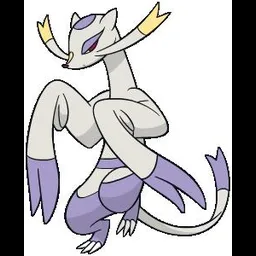

In [11]:
transform = transforms.Compose([
    dh.PadToRectangle(256,256),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

imgds = dh.ImageDataset(bds, transform)
next(iter(imgds))
imgds[10]
ih.tensor_to_pil(imgds[10])


## Bit predictor

In [41]:
batch = next(iter(dl))
batch.shape
autoencoder.forward(batch)[0].shape, autoencoder.encode(batch).shape

(torch.Size([2, 3, 256, 256]), torch.Size([2, 32, 32, 32]))

In [ ]:
autoencoder.forward()

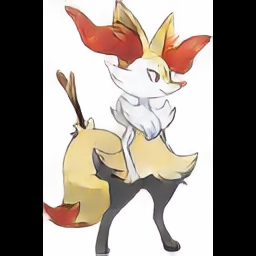

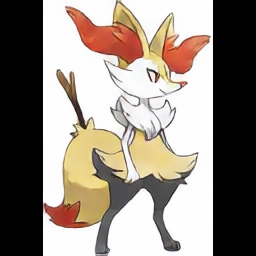

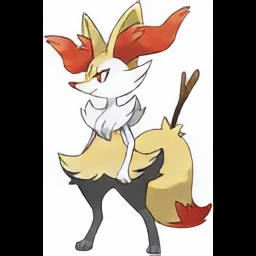

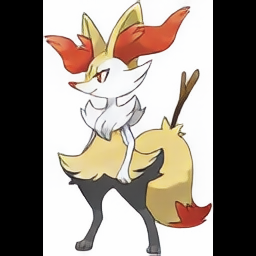

yay


In [42]:
dl = DataLoader(imgds)

for desired_bits in (1,2,3,4):
    dl = DataLoader(imgds, batch_size=2)
    batch = next(iter(dl))
    latents = autoencoder.encode(batch)
    pqlatents = autoencoder.pre_quant(latents)
    q_out, q_aux = autoencoder.quantizer(pqlatents)
    bit_codes = q_aux.bit_codes >> (4-desired_bits)
    qlatents = bit_codes_to_quantized_latent(bit_codes,desired_bits)
    #qlatents = torch.flip(qlatents,[3])
    rlatents = autoencoder.post_quant(qlatents)
    #latent = einx.id("B H W C -> B C H W",latent)
    ao = autoencoder.decode(rlatents)
    ipd.display(ih.tensor_to_pil(ao[0]))
print("yay")


In [ ]:
# Make a derived dataset

In [ ]:
import einx
import io

ds = dh.BlobDataset("data/dbs/pokemon_256x256.sqlite3", mode="r")

transform = transforms.Compose([
    dh.PadToRectangle(256,256),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

def tensor_to_bytes(t):
    buffer = io.BytesIO()
    torch.save(t, buffer)
    tensor_bytes = buffer.getvalue()
    return tensor_bytes
def bytes_to_tensor(tensor_bytes):
    buffer = io.BytesIO(tensor_bytes)
    restored_tensor = torch.load(buffer, weights_only=True)
    return restored_tensor

with torch.inference_mode():
    with dh.BlobDataset("/tmp/quantized_latents.db", "w") as derived:
        for hash_, data, columns in ds:
            img = Image.open(io.BytesIO(data)).convert("RGB")
            img_tensor = transform(img)
            batch = einx.id("C H W -> 1 C H W", img_tensor)
            latents = autoencoder.encode(batch)
            pqlatents = autoencoder.pre_quant(latents)
            q_out, q_aux = autoencoder.quantizer(pqlatents)
            bit_codes = q_aux.bit_codes[0] # [C, H, W]
            print(bit_codes.shape)
            derived.write(
                hash_,
                tensor_to_bytes(bit_codes),
                columns,
            )

torch.Size([16, 32, 32])
torch.Size([16, 32, 32])
torch.Size([16, 32, 32])
torch.Size([16, 32, 32])
torch.Size([16, 32, 32])
torch.Size([16, 32, 32])
torch.Size([16, 32, 32])
torch.Size([16, 32, 32])
torch.Size([16, 32, 32])
torch.Size([16, 32, 32])
torch.Size([16, 32, 32])
torch.Size([16, 32, 32])
torch.Size([16, 32, 32])
torch.Size([16, 32, 32])
torch.Size([16, 32, 32])
torch.Size([16, 32, 32])
torch.Size([16, 32, 32])
torch.Size([16, 32, 32])
torch.Size([16, 32, 32])
torch.Size([16, 32, 32])
torch.Size([16, 32, 32])
torch.Size([16, 32, 32])
torch.Size([16, 32, 32])
torch.Size([16, 32, 32])
torch.Size([16, 32, 32])
torch.Size([16, 32, 32])
torch.Size([16, 32, 32])
torch.Size([16, 32, 32])
torch.Size([16, 32, 32])
torch.Size([16, 32, 32])
torch.Size([16, 32, 32])
torch.Size([16, 32, 32])
torch.Size([16, 32, 32])
torch.Size([16, 32, 32])
torch.Size([16, 32, 32])
torch.Size([16, 32, 32])
torch.Size([16, 32, 32])
torch.Size([16, 32, 32])
torch.Size([16, 32, 32])
torch.Size([16, 32, 32])


KeyboardInterrupt: 